# **function and initial and boundary condition**

function：$u_{xx} + u_{yy} = -2\pi^2 \sin(\pi x) \cos(\pi y) + 6xy^2 + 2x^3$

analytical solution：$u(x, y) = \sin(\pi x) \cos(\pi y) + x^3 y^2$

ic&bc：$u(-1, y) = -y^2, u(1, y) = y^2, u(x, -1) = -\sin(\pi x) + x^3, u(x, 1) = -\sin(\pi x) + x^3$

sampling region：$\Omega =[-1,1]\times[-1,1]$

# import packages

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import Function
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import math

# FNN

In [2]:
class FNN(nn.Module):
    def __init__(self, layers, device):
        super(FNN, self).__init__()
        self.func = nn.Tanh  # activation function
        self.layers = layers
        self.device = device
        self.model = self.create_model().to(self.device)

    def create_model(self):
        layers_list = []
        for i in range(len(self.layers) - 1):
            layers_list.append(nn.Linear(self.layers[i], self.layers[i + 1]))
            if i < len(self.layers) - 2:
                layers_list.append(self.func())
        return nn.Sequential(*layers_list)

    def forward(self, X):
        out = self.model(X)
        return out

# PINN

In [ ]:
# 1. 定义梯度翻转层 (放在类外面即可)
class GradientReversal(Function):
    @staticmethod
    def forward(ctx, x, lambd=1.0):
        ctx.lambd = lambd
        return x
    @staticmethod
    def backward(ctx, grad_output):
        # 梯度取反，让参数朝着增大 Loss 的方向更新
        return grad_output.neg() * ctx.lambd, None

class normal_pinn():
    def __init__(self, layers, device, ):
        self.device = device
        self.layers = layers
        self.net = FNN(layers, device)
            
        self.loss_history = []
        self.loss_compute = None
        

        self.raw_alpha = nn.Parameter(torch.tensor(0.0, device=device, dtype=torch.float32))
        self.raw_beta  = nn.Parameter(torch.tensor(0.1, device=device, dtype=torch.float32))
        self.raw_gamma = nn.Parameter(torch.tensor(0.0, device=device, dtype=torch.float32))
        
        self.optimizer_adam = torch.optim.Adam(self.net.parameters(), lr=1e-3)
        
        self.optimizer_hyper = torch.optim.Adam(
            [
            {'params': [self.raw_alpha, self.raw_beta], 'lr': 1e-3, 'weight_decay': 1e-6},
            
            {'params': [self.raw_gamma], 'lr':1e-5}    # , 'weight_decay': 1e-6} ,
            ]
        )

        self.optimizer_lbfgs = torch.optim.LBFGS(
            self.net.parameters(),
            lr=1.0,
            max_iter=50000,
            max_eval=50000,
            history_size=50,
            tolerance_grad=1e-5,
            tolerance_change=1.0 * np.finfo(float).eps,
            line_search_fn="strong_wolfe"
        )
        self.iter = 0
        self.epochs = 0
        self.loss_history = []

    def get_adv_hyperparams(self):
        
        alpha_min = 0
        alpha_max =10.0
        alpha = alpha_min + (alpha_max - alpha_min) * torch.sigmoid(self.raw_alpha - 5.0)   # 用偏移的sigmoid函数，保证后期的权重能够下降或者近似下降到最小值
        
        beta_min = 0.1
        beta_max = 2.0
        beta = beta_min + (beta_max - beta_min) * torch.sigmoid(self.raw_beta - 5.0)
        
        gamma_min = -3.0
        gamma_max = 3.0
        gamma = gamma_min + (gamma_max - gamma_min) * torch.sigmoid(self.raw_gamma)
        return GradientReversal.apply(alpha), GradientReversal.apply(beta), GradientReversal.apply(gamma)

    def configure_scheduler(self, scheme="none"):
        scheme = (scheme or "none").lower()
        self.scheduler_adam = None
        self.scheduler_lbfgs = None
        if scheme == "exp":
            self.scheduler_adam = torch.optim.lr_scheduler.ExponentialLR(
                self.optimizer_adam, gamma=0.9
            )
            self.scheduler_lbfgs = torch.optim.lr_scheduler.ExponentialLR(
                self.optimizer_lbfgs, gamma=0.9
            )
        elif scheme == "plateau":
            self.scheduler_adam = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer_adam, mode="min", factor=0.9, patience=5000, min_lr=1e-6
            )
            self.scheduler_lbfgs = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer_lbfgs, mode="min", factor=0.9, patience=400, min_lr=1e-6
            )

    def net_u(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        u = self.net(inputs)
        return u

    def loss_compute_updata(self, loss_compute, X_bc_train, X_f_train, device, config=None):
        # Helmholtz equation has no IC, so we remove X_ic_train
        self.loss_compute = loss_compute(
            self,
            X_bc_train,
            X_f_train,
            device,
            config,
        )

    def loss(self):
        loss_pde, loss_bc = self.loss_compute.loss_compute()
        total_loss = self.loss_compute.weighted_loss(loss_pde, loss_bc)
        return total_loss, loss_pde, loss_bc

    def train(self,
              epochs=1000,
              print_every=100,
              opt_type='adam',
              scheduler='none',
              plot_judge='No',
              plot_type='none',
              plot_every=None,
              save_dir=None
             ):
        self.epochs = epochs
        if plot_every is None:
            plot_every = epochs
        opt_type = (opt_type or "adam").lower()
        if opt_type not in {"adam", "lbfgs"}:
            raise ValueError(f"Unsupported opt_type '{opt_type}'. Expected 'adam' or 'lbfgs'.")
        self.configure_scheduler(scheduler)
        self.net.train()

        if opt_type == "adam":
            optimizer = self.optimizer_adam
            scheduler_obj = self.scheduler_adam
            
            for epoch in range(1, self.epochs + 1):
                optimizer.zero_grad()
                self.optimizer_hyper.zero_grad() # 新增：清空超参数梯度
                
                total_loss, loss_pde, loss_bc = self.loss()
                total_loss.backward()
                
                optimizer.step()
                if epoch > 2000:
                    self.optimizer_hyper.step()  
                
                if scheduler_obj is not None:
                    if isinstance(scheduler_obj, torch.optim.lr_scheduler.ReduceLROnPlateau):
                        scheduler_obj.step(total_loss.item())
                    else:
                        scheduler_obj.step()
                self.iter += 1
                eff_alpha, eff_beta, eff_gamma = self.get_adv_hyperparams()
                history_entry = {
                    "epoch": self.iter,
                    "total": total_loss.item(),
                    "pde": loss_pde.item(),
                    "bc": loss_bc.item(),
                    "stage": "adam",
                    "alpha": eff_alpha.item(),
                    "beta": eff_beta.item(),
                    "gamma": eff_gamma.item(),
                }
                self.loss_history.append(history_entry)
                
                if print_every and epoch % print_every == 0:                    
                    current_alpha = eff_alpha.item()
                    current_beta  = eff_beta.item()
                    current_gamma = eff_gamma.item()
                    
                    print(
                        f"[Adam] Epoch {self.iter}: total={total_loss.item():.4e}, "
                        f"pde={loss_pde.item():.4e}, bc={loss_bc.item():.4e} | "
                        f"Adv[α={current_alpha:.2f}, β={current_beta:.2f}, γ={current_gamma:.4f}]"
                    )
                if plot_judge != 'No' and epoch % plot_every == 0:
                        self.loss_compute.point_scater(plot_type=plot_type, save_dir=save_dir, name=f'[Adam]epoch[{epoch}:{self.epochs}]')
        else:
            optimizer = self.optimizer_lbfgs
            scheduler_obj = self.scheduler_lbfgs
            
            def closure():
                optimizer.zero_grad()
                self.optimizer_hyper.zero_grad() 
                
                total_loss, _, _ = self.loss()
                total_loss.backward()
                return total_loss

            for epoch in range(1, self.epochs + 1):
                optimizer.step(closure)
                
                self.optimizer_hyper.zero_grad()
                total_loss, loss_pde, loss_bc = self.loss()
                total_loss.backward()
                self.optimizer_hyper.step()

                if scheduler_obj is not None:
                    if isinstance(scheduler_obj, torch.optim.lr_scheduler.ReduceLROnPlateau):
                        scheduler_obj.step(total_loss.item())
                    else:
                        scheduler_obj.step()
                self.iter += 1
                history_entry = {
                    "epoch": self.iter,
                    "total": total_loss.item(),
                    "pde": loss_pde.item(),
                     #"ic": loss_ic.item(),
                    "bc": loss_bc.item(),
                    "stage": "lbfgs",
                }
                self.loss_history.append(history_entry)

                if print_every and epoch % print_every == 0:
                    # 修改这里：使用统一的方法获取当前生效的超参数
                    eff_alpha, eff_beta, eff_gamma = self.get_adv_hyperparams()
                    current_alpha = eff_alpha.item()
                    current_beta  = eff_beta.item()
                    current_gamma = eff_gamma.item()
                    
                    print(
                        f"[LBFGS] Epoch {self.iter}: total={total_loss.item():.4e}, "
                        f"pde={loss_pde.item():.4e}, bc={loss_bc.item():.4e} | "
                        f"Adv[α={current_alpha:.2f}, β={current_beta:.2f}, γ={current_gamma:.4f}]"
                    )
                if plot_judge != 'No' and epoch % plot_every == 0:
                        self.loss_compute.point_scater(plot_type=plot_type, save_dir=save_dir, name=f'[LBFGS]epoch[{epoch}:{self.epochs}]')

        return self.loss_history

    def predict(self, X):
        if isinstance(X, np.ndarray):
            X_tensor = torch.tensor(X, dtype=torch.float32, device=self.device)
        else:
            X_tensor = X.to(self.device)
        x = X_tensor[:, 0:1]
        y = X_tensor[:, 1:2]
        self.net.eval()
        with torch.no_grad():
            u = self.net_u(x, y)
        return u.cpu().numpy()
        
    def save_model(self, file_path):
        directory = os.path.dirname(file_path)
        if directory and not os.path.exists(directory):
            os.makedirs(directory, exist_ok=True)

        state = {
            'net_state_dict': self.net.state_dict(),
            'optimizer_adam_state_dict': self.optimizer_adam.state_dict(),
            'optimizer_lbfgs_state_dict': self.optimizer_lbfgs.state_dict(),
            # 新增：保存超参数和其优化器状态
            'raw_alpha': self.raw_alpha,
            'raw_beta': self.raw_beta,
            'raw_gamma': self.raw_gamma,
            'optimizer_hyper_state_dict': self.optimizer_hyper.state_dict(),
            'loss_history': self.loss_history,
            'iter': self.iter,
            'layers': self.layers,
        }
        torch.save(state, file_path)
        print(f"Model saved successfully to {file_path}")

    def load_model(self, file_path):
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")
            
        checkpoint = torch.load(file_path, map_location=self.device)
        
        if 'layers' in checkpoint and checkpoint['layers'] != self.layers:
             print("Warning: Loaded model layers do not match current model layers.")

        self.net.load_state_dict(checkpoint['net_state_dict'])
        self.optimizer_adam.load_state_dict(checkpoint['optimizer_adam_state_dict'])
        self.optimizer_lbfgs.load_state_dict(checkpoint['optimizer_lbfgs_state_dict'])
        
        # 新增：加载超参数
        if 'raw_alpha' in checkpoint:
            self.raw_alpha.data = checkpoint['raw_alpha'].data
            self.raw_beta.data = checkpoint['raw_beta'].data
            self.raw_gamma.data = checkpoint['raw_gamma'].data
            self.optimizer_hyper.load_state_dict(checkpoint['optimizer_hyper_state_dict'])
        
        self.loss_history = checkpoint['loss_history']
        self.iter = checkpoint['iter']
        print(f"Model loaded successfully from {file_path}, current iter: {self.iter}")

# LossCompute

In [5]:
class LossCompute():
    def __init__(self, model, X_bc_train, X_f_train, device, config=None):
        self.model = model
        self.device = device
        self.config = config or {}
        
        default_weights = {"pde": 1.0, "bc": 1.0}
        custom_weights = self.config.get("weights", {})
        self.weights = {**default_weights, **custom_weights}
        
        default_pointwise_weights = {"pde": 1.0, "bc": 1.0}
        custom_pointwise_weights = self.config.get('pointwise_weights', {})
        self.pointwise_weights = {**default_pointwise_weights, **custom_pointwise_weights}

        self.x_bc = torch.tensor(X_bc_train[:, 0:1], dtype=torch.float32, device=device, requires_grad=True)
        self.y_bc = torch.tensor(X_bc_train[:, 1:2], dtype=torch.float32, device=device, requires_grad=True)
        # Dirichlet BC
        self.u_bc = torch.tensor(X_bc_train[:, 2:3], dtype=torch.float32, device=device) 

        self.x_f = torch.tensor(X_f_train[:, 0:1], dtype=torch.float32, device=device, requires_grad=True)
        self.y_f = torch.tensor(X_f_train[:, 1:2], dtype=torch.float32, device=device, requires_grad=True)

        self.residual = {'pde': None, 'bc': None}

    def gradient(self, func, var, order=1):
        if order == 1:
            return torch.autograd.grad(
                func, var, grad_outputs=torch.ones_like(func),
                retain_graph=True, create_graph=True
            )[0]
        else:
            out = self.gradient(func, var)
            return self.gradient(out, var, order - 1)
        
    def _resolve_weight(self, key):
        weight = self.weights.get(key, 1.0)
        if callable(weight): weight = weight()
        if not torch.is_tensor(weight):
            weight = torch.as_tensor(weight, dtype=torch.float32, device=self.device)
        return weight
    
    def _resolve_pointwise_weight(self, key, ref_tensor):
        weight = self.pointwise_weights.get(key, 1.0)
        if callable(weight): weight = weight()
        if not torch.is_tensor(weight):
            weight = torch.as_tensor(weight, dtype=torch.float32, device=self.device)
        if weight.ndim == 0 and ref_tensor is not None:
            weight = weight.expand_as(ref_tensor)
        return weight
    
    def f_source(self, x, y):
        # f(x,y) for Poisson equation with u = sin(pi*x)*cos(pi*y) + x^3*y^2
        # u_xx + u_yy = f
        # f = -2*pi^2*sin(pi*x)*cos(pi*y) + 6*x*y^2 + 2*x^3
        return -2.0 * (np.pi ** 2) * torch.sin(np.pi * x) * torch.cos(np.pi * y) + 6.0 * x * (y ** 2) + 2.0 * (x ** 3)

    def loss_pde(self):
        self.x_f.requires_grad_(True)
        self.y_f.requires_grad_(True)
        x = self.x_f
        y = self.y_f
        u = self.model.net_u(x, y)
        
        u_x = self.gradient(u, x)
        u_xx = self.gradient(u_x, x)
        u_y = self.gradient(u, y)
        u_yy = self.gradient(u_y, y)
        
        f = self.f_source(x, y)
        
        # Poisson: u_xx + u_yy - f = 0
        residual = u_xx + u_yy - f
        
        self.residual['pde'] = residual.abs().detach()
        weight = self._resolve_pointwise_weight('pde', x)
        residual = weight * residual
        return torch.mean(residual**2)

    def loss_bc(self):
        # Dirichlet BC
        u_pred = self.model.net_u(self.x_bc, self.y_bc)
        residual = (u_pred - self.u_bc).abs().detach()
        self.residual['bc'] = residual
        
        weight = self._resolve_pointwise_weight('bc', self.x_bc)
        bc_err = weight * (u_pred - self.u_bc)
        return torch.mean(bc_err**2)

    def weighted_loss(self, loss_pde, loss_bc):
        w_pde = self._resolve_weight("pde")
        w_bc = self._resolve_weight("bc")
        return w_pde * loss_pde + w_bc * loss_bc

    def loss_compute(self):
        loss_pde = self.loss_pde()
        loss_bc = self.loss_bc()
        return loss_pde, loss_bc
    
    def up_data(self, X_f_new):  
        self.x_f = torch.tensor(X_f_new[:, 0:1], dtype=torch.float32, device=self.device)
        self.y_f = torch.tensor(X_f_new[:, 1:2], dtype=torch.float32, device=self.device)
        self.x_f.requires_grad_(True)
        self.y_f.requires_grad_(True)

    def updata_config(self, config):
        self.config = config
        default_weights = {"pde": 1.0, "bc": 1.0}
        custom_weights = self.config.get("weights", {})
        self.weights = {**default_weights, **custom_weights}
        default_pointwise_weights = {"pde": 1.0, "bc": 1.0}
        custom_pointwise_weights = self.config.get('pointwise_weights', {})
        self.pointwise_weights = {**default_pointwise_weights, **custom_pointwise_weights}

    def point_scater(self, plot_type='none', cmap='viridis', f_s=1, bc_s=1, save_dir=None, name=None):
        mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Times", "serif"],
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        })
        plt.figure(figsize=(6, 6))
        x_f = self.x_f.detach().cpu().numpy().ravel()
        y_f = self.y_f.detach().cpu().numpy().ravel()
        x_bc = self.x_bc.detach().cpu().numpy().ravel()
        y_bc = self.y_bc.detach().cpu().numpy().ravel()

        if plot_type == 'weighted':
            w_f = self._resolve_pointwise_weight('pde', self.x_f)
            w_bc = self._resolve_pointwise_weight('bc', self.x_bc)
            
            w_f = w_f.detach().cpu().numpy().ravel() if torch.is_tensor(w_f) else np.asarray(w_f).ravel()
            w_bc = w_bc.detach().cpu().numpy().ravel() if torch.is_tensor(w_bc) else np.asarray(w_bc).ravel()
            
            arrs = [a for a in (w_f, w_bc) if a is not None and a.size > 0]
            if not arrs: raise RuntimeError("No weights available for plotting.")
            vmin, vmax = min(a.min() for a in arrs), max(a.max() for a in arrs)
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

            plt.scatter(x_f, y_f, c=w_f, cmap=cmap, norm=norm, s=f_s, marker='o', alpha=0.9, label='collocation')
            plt.scatter(x_bc, y_bc, c=w_bc, cmap=cmap, norm=norm, s=bc_s, marker='x', linewidths=1.0, label='BC')
            
            sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
            sm.set_array(np.concatenate([a.ravel() for a in arrs]))
            cbar = plt.colorbar(sm, ax=plt.gca())
            cbar.set_label('w')
        else:
            plt.scatter(x_f, y_f, s=f_s, marker='o', alpha=0.9, label='collocation')
            plt.scatter(x_bc, y_bc, s=bc_s, marker='x', color='r', linewidths=1.0, label='BC')
            
        plt.xlabel('x'); plt.ylabel('y')
        plt.title('Points Scatter')
        plt.legend(loc='best')
        plt.tight_layout()
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(os.path.join(save_dir, f"{name}_sample_location.png"), dpi=300)
        plt.show()
        plt.close()

# Loss History Visualize

In [6]:
def plot_loss_history(training_history, title="Training loss history", save_path=None):
    if not training_history:
        raise ValueError("training_history is empty.")
    epochs = np.array([entry["epoch"] for entry in training_history])
    loss_total = [entry["total"] for entry in training_history]
    loss_pde = [entry["pde"] for entry in training_history]
    loss_bc = [entry["bc"] for entry in training_history]
    lbfgs_start = next((entry["epoch"] for entry in training_history if entry.get("stage") == "lbfgs"), None)

    plt.figure(figsize=(8, 4))
    plt.semilogy(epochs, loss_total, label="total")
    plt.semilogy(epochs, loss_pde, label="pde")
    plt.semilogy(epochs, loss_bc, label="bc")

    if lbfgs_start is not None:
        plt.axvline(lbfgs_start, color="k", linestyle="--", alpha=0.4)
        plt.text(lbfgs_start, max(loss_total), " LBFGS", va="bottom", ha="left", fontsize=9, color="k")

    plt.xlabel("Iteration")
    plt.ylabel("Loss (log scale)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        plt.savefig(save_path, dpi=300)
    plt.show()

def analytical_solution(x, y):
    return np.sin(np.pi * x) * np.cos(np.pi * y) + (x ** 3) * (y ** 2)

def plot_solution_comparison(model, x_plot, y_plot, title_prefix="PINN", save_dir=None, y_slices=None):
    X_grid, Y_grid = np.meshgrid(x_plot, y_plot)
    XY = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
    
    U_pred = model.predict(XY).reshape(X_grid.shape)
    U_ref = analytical_solution(X_grid, Y_grid)
    U_error = U_pred - U_ref
    abs_error = np.abs(U_error)
    
    l2_error = np.sqrt(np.mean(U_error ** 2))
    max_error = np.max(abs_error)
    print(f"{title_prefix} -> L2 error: {l2_error:.4e}, max abs error: {max_error:.4e}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    pcm0 = axes[0].pcolormesh(x_plot, y_plot, U_pred, shading="auto", cmap="RdBu_r")
    axes[0].set_title(f"{title_prefix} prediction")
    axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
    fig.colorbar(pcm0, ax=axes[0], label="u(x, y)")

    pcm1 = axes[1].pcolormesh(x_plot, y_plot, U_ref, shading="auto", cmap="RdBu_r")
    axes[1].set_title("Analytical solution")
    axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
    fig.colorbar(pcm1, ax=axes[1], label="u(x, y)")

    pcm2 = axes[2].pcolormesh(x_plot, y_plot, abs_error, shading="auto", cmap="viridis")
    axes[2].set_title(f"Absolute error")
    axes[2].set_xlabel("x"); axes[2].set_ylabel("y")
    fig.colorbar(pcm2, ax=axes[2], label="|error|")

    plt.tight_layout()

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, f"{title_prefix}_comparison.png"), dpi=300)        
    plt.show()
    plt.close(fig)

# Weight Function

In [7]:
def omega_weight(model, target):
    device = getattr(model, 'device', torch.device('cpu'))
    target = (target or '').lower()
    parts = target.split(':', 1)
    base_target = parts[0]

    def factory():
        loss_compute = getattr(model, "loss_compute", None)
        if loss_compute is None:
            raise AttributeError("LossCompute 尚未初始化，无法计算权重。")

        residual_store = loss_compute.residual.get(base_target)
        if residual_store is None:
                    raise RuntimeError(f"尚未为 {base_target} 计算 residual, 无法生成权重。请先执行对应的 loss 计算。")
        alpha, beta, gamma = model.get_adv_hyperparams()
        
        with torch.no_grad():
            residual = residual_store.detach()
            r_mean = residual.mean()
            r_std = residual.std(unbiased=False) + 1e-8
            r_normalized = (residual - r_mean) / r_std
        # with torch.no_grad():
        #     residual_abs = residual_store.abs().detach()
        #     r_median = torch.median(residual_abs)
        #     r_mad = torch.median(torch.abs(residual_abs - r_median)) + 1e-8
        #     r_normalized = (residual_abs - r_median) / r_mad

        attention_score = torch.sigmoid((r_normalized - gamma) * beta)
        s = 1.0 + alpha * attention_score
        w = s / (s.mean() + 1e-8)
        return w

    return factory

# Save Log Function

In [8]:
def save_log(save_dir,training_history):
    md_path = f"{save_dir}/train_epochs.md"
    os.makedirs(os.path.dirname(md_path) or ".", exist_ok=True)
    with open(md_path, "w", encoding="utf-8") as f:
        f.write("# 训练 Epoch 日志\n\n")
        f.write("| epoch | stage | total | pde | bc | ic | alpha | beta | gamma |\n")
        f.write("|---:|:---:|---:|---:|---:|---:|---:|---:|---:|\n")
        for e in training_history:
            if e['epoch']%10000 == 0:
                f.write(f"| {e['epoch']} | {e.get('stage','')} | {e['total']:.4e} | {e['pde']:.4e} | {e['bc']:.4e} |{e['ic']:.4e} |{e['alpha']:.4e} |{e['beta']:.4e} |{e['gamma']:.4e} |\n")
    print(f"Saved epoch log to {md_path}")
            

# Sampling

In [9]:
np.random.seed(1234)
torch.manual_seed(1234)
rng = np.random.default_rng(1234)

def latin_hypercube_sampling(bounds, n_samples, rng):
    dim = len(bounds)
    result = np.zeros((n_samples, dim))
    cut = np.linspace(0, 1, n_samples + 1)
    for i, (low, high) in enumerate(bounds):
        u = rng.random(n_samples)
        pts = cut[:-1] + u * (cut[1:] - cut[:-1])
        rng.shuffle(pts)
        result[:, i] = low + pts * (high - low)
    return result

# Boundary Conditions: 4 sides of the square [-1, 1] x [-1, 1]
N_bc_side = 100
# Left (-1, y)
y_bc = latin_hypercube_sampling([(-1.0, 1.0)], N_bc_side, rng)
x_left = -np.ones_like(y_bc)
bc_left = np.hstack([x_left, y_bc])
# Right (1, y)
x_right = np.ones_like(y_bc)
bc_right = np.hstack([x_right, y_bc])
# Bottom (x, -1)
x_bc = latin_hypercube_sampling([(-1.0, 1.0)], N_bc_side, rng)
y_bottom = -np.ones_like(x_bc)
bc_bottom = np.hstack([x_bc, y_bottom])
# Top (x, 1)
y_top = np.ones_like(x_bc)
bc_top = np.hstack([x_bc, y_top])

X_bc_points = np.vstack([bc_left, bc_right, bc_bottom, bc_top])
# Analytical solution on boundary is 0
U_bc_values = analytical_solution(X_bc_points[:, 0:1], X_bc_points[:, 1:2])
X_bc_train = np.hstack([X_bc_points, U_bc_values])

# Collocation Points
N_f = 1200
X_f_train = latin_hypercube_sampling([(-1.0, 1.0), (-1.0, 1.0)], N_f, rng)

# Weight Train

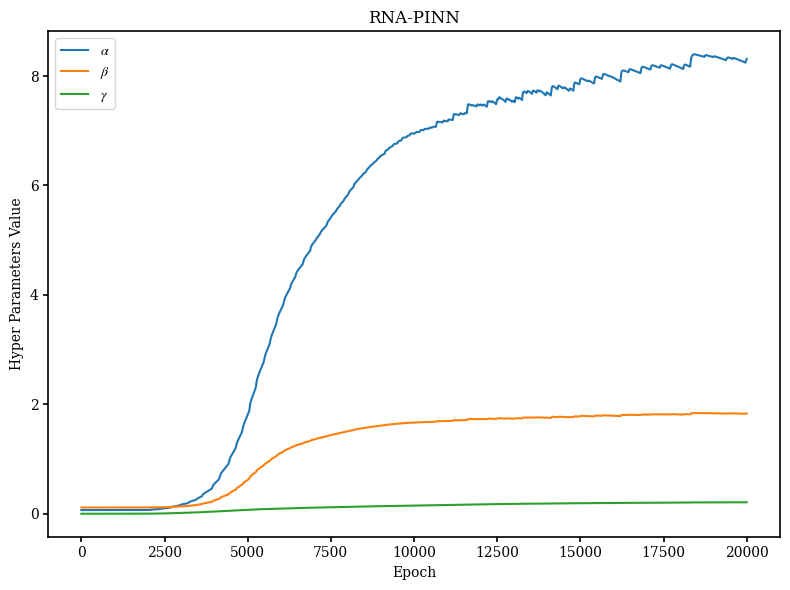

In [36]:
model_history = training_history
alpha = np.array([entry.get('alpha', np.nan) for entry in model_history], dtype=np.float32)
beta = np.array([entry.get('beta', np.nan) for entry in model_history], dtype=np.float32)
gamma = np.array([entry.get('gamma', np.nan) for entry in model_history], dtype=np.float32)

x = np.arange(1, len(model_history) + 1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, alpha, label=r"$\alpha$")
ax.plot(x, beta, label=r"$\beta$")
ax.plot(x, gamma, label=r"$\gamma$")
ax.set_xlabel("Epoch")
ax.set_ylabel("Hyper Parameters Value")
ax.set_title("RNA-PINN")
ax.legend()
plt.tight_layout()
plt.show()

current train model:RNA-PINN
Using device cuda
[Adam] Epoch 10000: total=7.0970e-03, pde=3.3553e-03, bc=3.7417e-05 | Adv[α=0.21, β=1.54, γ=0.0038]


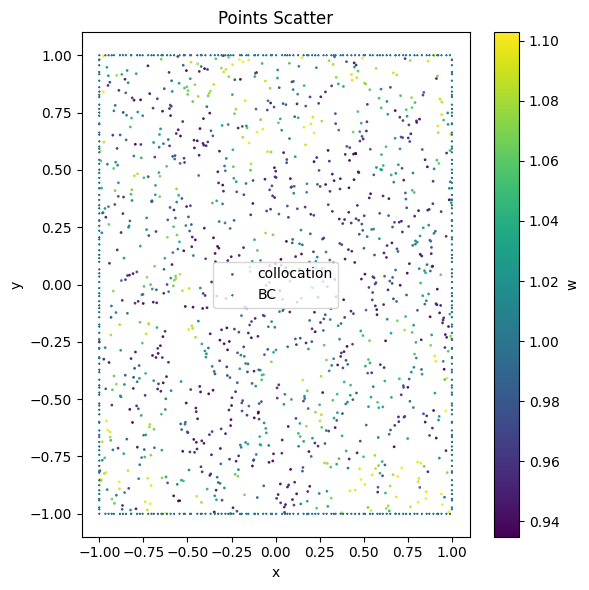

[Adam] Epoch 20000: total=8.3083e-04, pde=7.3280e-04, bc=9.8036e-07 | Adv[α=3.34, β=1.95, γ=0.0633]


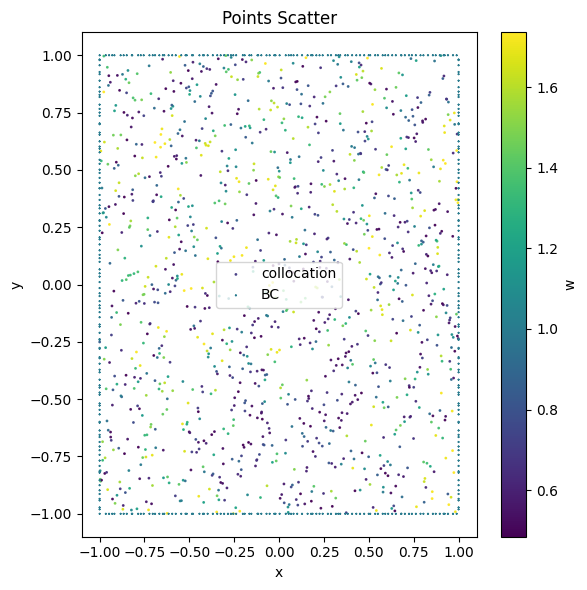

Model saved successfully to Possion/RNA-PINN/RNA-PINN.pth


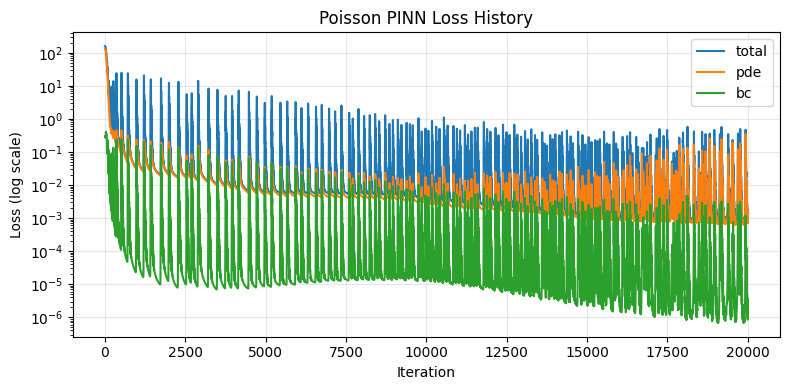

Poisson -> L2 error: 4.7094e-04, max abs error: 2.8055e-03


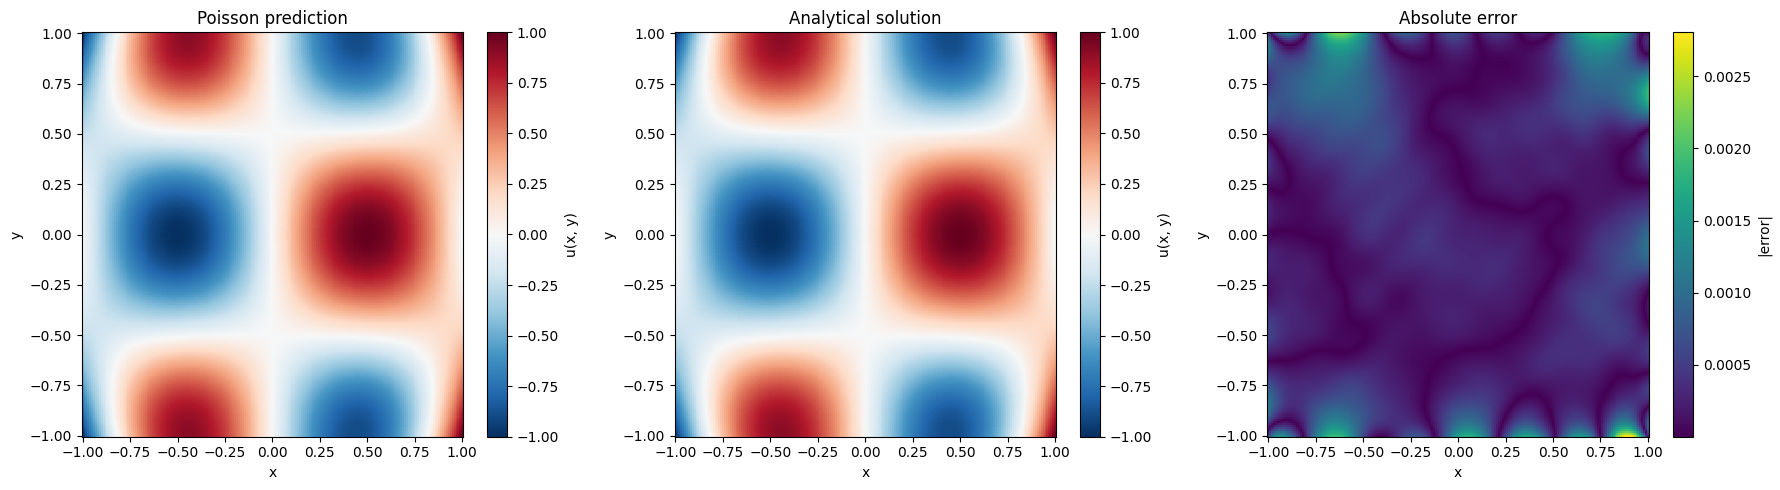

In [ ]:
model = 'RNA-PINN'
print(f'current train model:{model}')
save_dir = 'Possion/'+model
layers = [2,128,128,128,128,1]
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f'Using device {device}')
epochs = 20000
pinn_curr = normal_pinn(
    layers = layers,
    device = device,
)
pinn_curr.loss_compute_updata(LossCompute,X_bc_train,X_f_train,device)

pde_weight = omega_weight(pinn_curr, "pde")
loss_config = {'weights':{'pde':1,'bc':100},
               'pointwise_weights':{'pde':pde_weight}
               }
pinn_curr.loss_compute.updata_config(loss_config)

training_history = pinn_curr.train(
    epochs=epochs,
    print_every=10000,
    opt_type= 'adam',
    scheduler='plateau',
    plot_judge = 'Yes',
    plot_every = 10000,
    plot_type = 'weighted',
    save_dir=f"{save_dir}/sample_weight&location",
)

# save model
save_path = f"{save_dir}/{model}.pth"
pinn_curr.save_model(save_path)

# Loss Log
plot_loss_history(
    training_history,
    title="Poisson PINN Loss History",
    save_path=f"{save_dir}/loss_history.png",
)

# Visualize
x_plot = np.linspace(-1, 1, 200)
y_plot = np.linspace(-1, 1, 200)
plot_solution_comparison(
    model=pinn_curr,
    x_plot=x_plot,
    y_plot=y_plot,
    title_prefix="Poisson",
    save_dir=save_dir,
)